In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

%cd /g/data/w42/dr6273/work/wind_drought/
import utils

/g/data/w42/dr6273/work/wind_drought


In [3]:
%load_ext autoreload
%autoreload 2

### Load BARRA-R2 wind speed data

In [6]:
obs_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_nem-2030.nc'

In [7]:
ds_obs = xr.open_dataset(obs_infile)
ds_obs = ds_obs.compute()


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: /g/data/w42/dr6273/work/unseen_venv/bin/python3 -m pip install --upgrade pip


In [9]:
ds_obs

<xarray.Dataset> Size: 68kB
Dimensions:  (time: 4232)
Coordinates:
  * time     (time) datetime64[ns] 34kB 1980-05-01T12:00:00 ... 2025-07-31T12...
Data variables:
    sfcWind  (time) float64 34kB 3.886 4.319 4.307 4.119 ... 2.612 3.348 3.062
Attributes: (12/61)
    CDI:                       Climate Data Interface version 2.4.3 (https://...
    Conventions:               CF-1.10, ACDD-1.3
    source:                    Data from Met Office Unified Model (UM, versio...
    institution:               Bureau of Meteorology
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        88.48
    geospatial_lon_max:        207.39
    geospatial_lon_units:      degrees_east
    history:                   Mon May 11 11:26:42 2026: cdo mergetime sfcWin...
    CDO:                       Climate Data Operators version 2.4.3 (https://...

In [10]:
sfcWind_obs_data = ds_obs['sfcWind'].values

In [13]:
pctl10_obs = np.percentile(sfcWind_obs_data, 10)

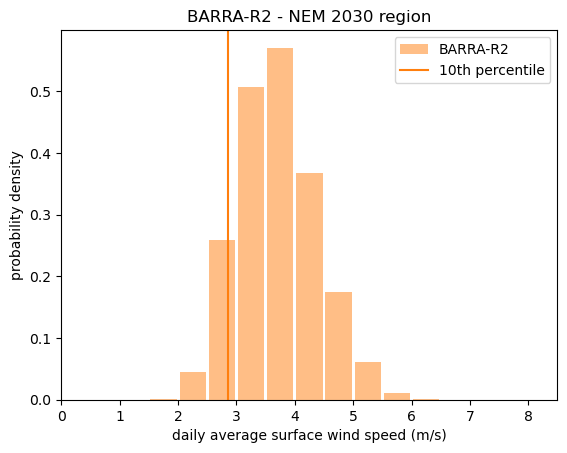

In [14]:
bins = np.arange(0, 9.5, 0.5)
plt.hist(sfcWind_obs_data, bins=bins, density=True, rwidth=0.9, label='BARRA-R2', color='tab:orange', alpha=0.5)
plt.axvline(pctl10_obs, color='tab:orange', label='10th percentile')
plt.xlabel('daily average surface wind speed (m/s)')
plt.ylabel('probability density')
plt.title('BARRA-R2 - NEM 2030 region')
plt.xlim(0, 8.5)
plt.legend()
plt.show()

### Calculate annual maximum wind drought duration (WDDx)

In [15]:
wddx_obs = utils.calc_wddx_obs(ds_obs, pctl10_obs)

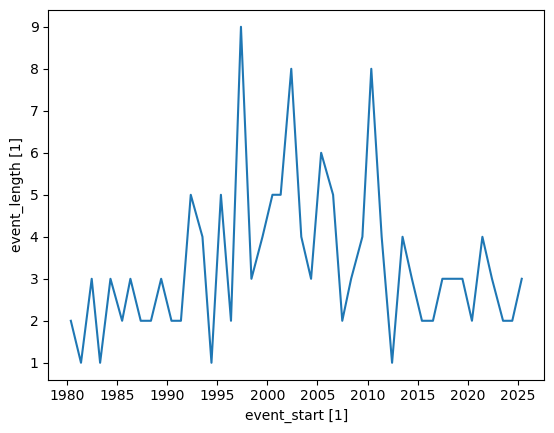

In [22]:
wddx_obs["event_length"].plot()

In [17]:
years = wddx_obs['event_start'].dt.year.values
df = pd.DataFrame(index=years)
df['WDDx'] = wddx_obs['event_length'].values
df['start_date'] = wddx_obs['event_start'].dt.strftime('%Y-%m-%d')
df.sort_values(['WDDx'], ascending=False).head(n=10)

,WDDx,start_date
1997,9.0,1997-05-16
2002,8.0,2002-05-22
2010,8.0,2010-05-14
2005,6.0,2005-05-14
1992,5.0,1992-05-14
2001,5.0,2001-05-01
2000,5.0,2000-07-06
2006,5.0,2006-07-23
1995,5.0,1995-05-17
1999,4.0,1999-07-09


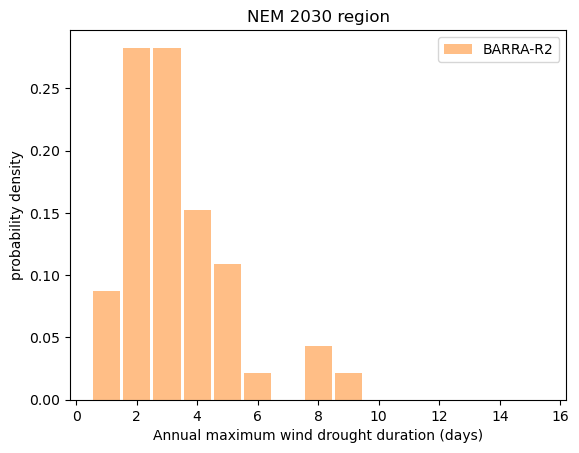

In [18]:
bins = np.arange(0.5, 16.5, 1)

plt.hist(
    wddx_obs['event_length'].values,
    bins=bins,
    density=True,
    rwidth=0.9,
    label='BARRA-R2',
    color='tab:orange',
    alpha=0.5
)
plt.xlabel('Annual maximum wind drought duration (days)')
plt.ylabel('probability density')
plt.title('NEM 2030 region')
plt.legend()
plt.show()

### MSLP

In [71]:
import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [33]:
psl_path = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/day/psl/latest/'

In [28]:
top10 = df.sort_values(['WDDx'], ascending=False).head(n=10)

In [29]:
top10

,WDDx,start_date
1997,9.0,1997-05-16
2002,8.0,2002-05-22
2010,8.0,2010-05-14
2005,6.0,2005-05-14
1992,5.0,1992-05-14
2001,5.0,2001-05-01
2000,5.0,2000-07-06
2006,5.0,2006-07-23
1995,5.0,1995-05-17
1999,4.0,1999-07-09


In [102]:
def plot_event_psl(event_id):
    """
    Plot maps of events
    """
    # Event stats
    duration, start = top10.iloc[event_id]
    year, month, day = start.split('-')

    # PSL for event month
    psl_fname = 'psl_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_'
    psl_month = xr.open_mfdataset(
        psl_path + psl_fname + year + month + '-' + year + month + '.nc'
    )['psl']

    # PSL for event
    psl_event = psl_month.where(
        (psl_month.time.dt.day >= int(day)) & (psl_month.time.dt.day < int(day) + int(duration)),
        drop=True
    )

    fig, ax = plt.subplots(3, 3, subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(8,7))
    for i in range(int(duration)):
        CS = (psl_event / 100).isel(time=i).plot.contour(ax=ax.flatten()[i])
        ax.flatten()[i].set_title('Day ' + str(i+1))#psl_event.isel(time=i).time.values)
        # ax.flatten()[i].clabel(CS, inline=True, fontsize=10)
    
    for ax in ax.flatten():
        ax.coastlines()
        ax.set_extent([90, 180, 0, -49])
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    plt.tight_layout()

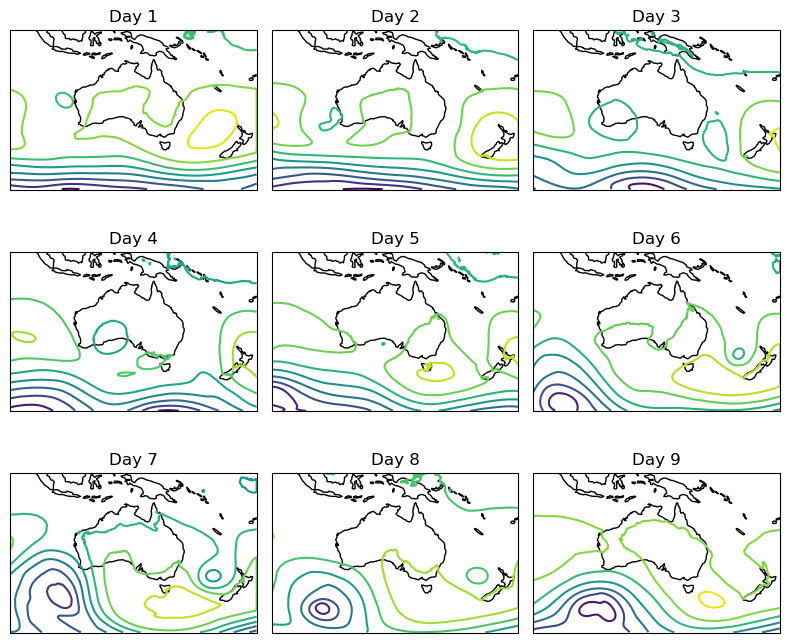

In [103]:
plot_event_psl(0)

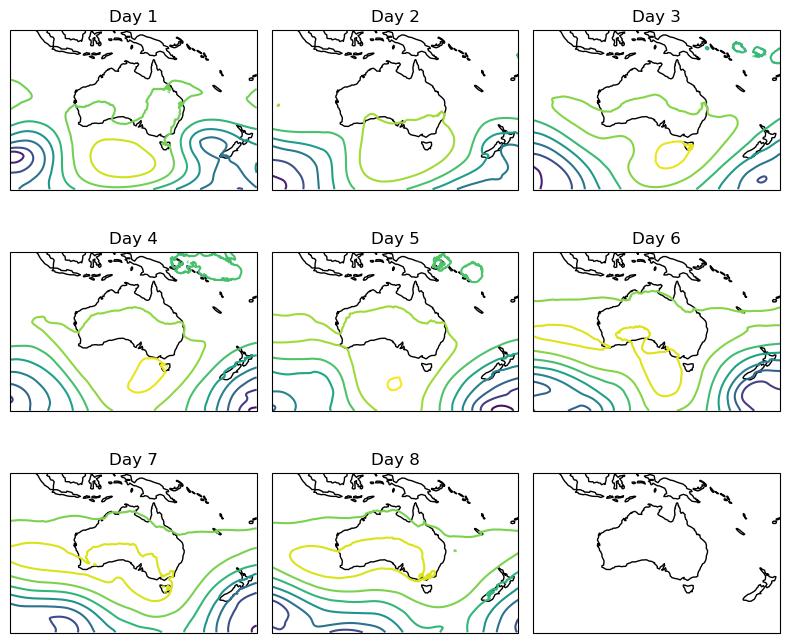

In [104]:
plot_event_psl(1)

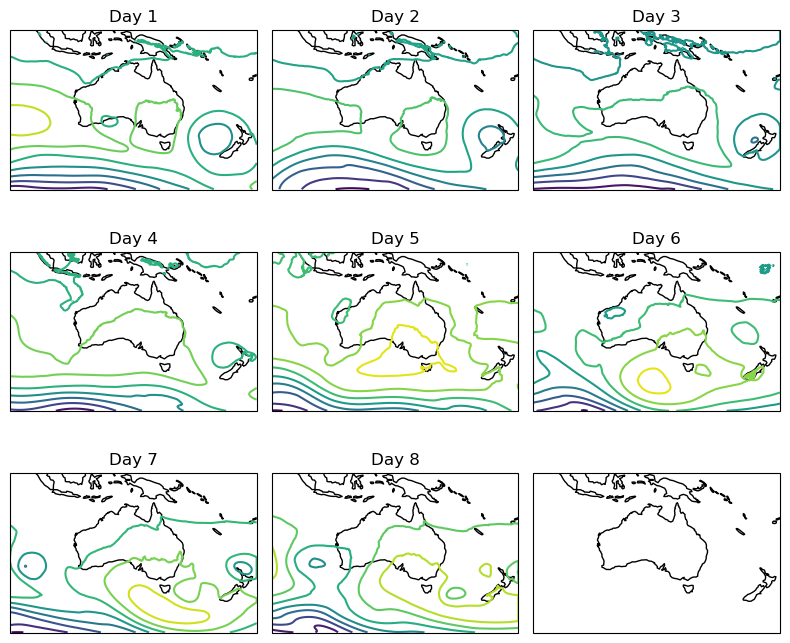

In [105]:
plot_event_psl(2)

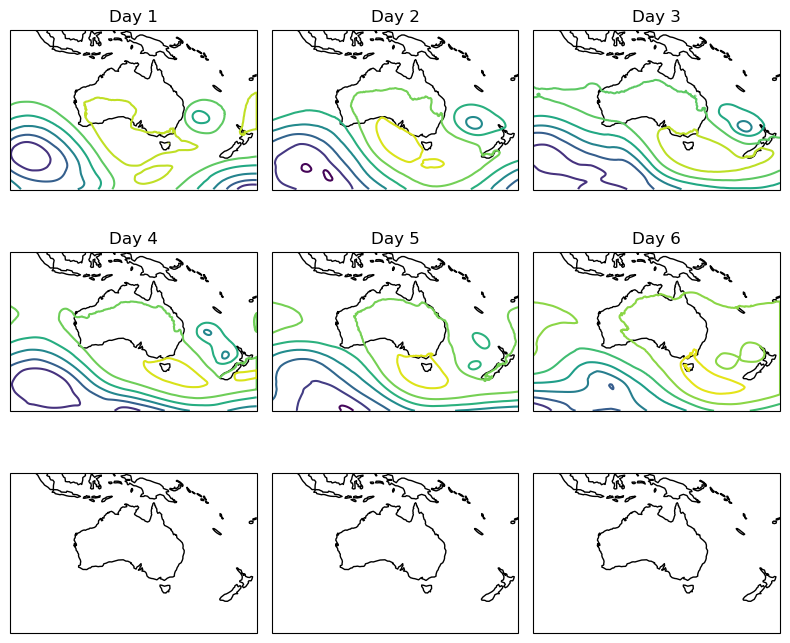

In [106]:
plot_event_psl(3)